# Ordinary Differential Equations: From Growth to Oscillations

## Mathematics for Biology

In this notebook we develop ordinary differential equations (ODEs) step by step.

We will begin with a simple first-order ODE describing growth or decay. We then introduce numerical solutions and move to a horizontal spring–mass system. This leads naturally to second-order ODEs, harmonic oscillations, damping, resonance, and phase-space plots.

At the end we transfer these ideas to a **biological oscillator: the Lotka–Volterra predator–prey model**.

### Learning goals

After working through this notebook, you should be able to:

- explain what an ordinary differential equation is,
- distinguish an ODE from its solution,
- understand the role of initial conditions,
- solve simple first-order ODEs,
- understand Euler's method,
- recognize first- and second-order ODEs,
- solve the harmonic oscillator,
- use complex exponentials to solve linear ODEs,
- distinguish weak damping, critical damping, and overdamping,
- interpret trajectories in phase space,
- understand the steady-state response of a driven oscillator,
- interpret resonance, amplitude, and phase,
- apply ODE ideas to a biological oscillator.

## 1. What is an ordinary differential equation?

A differential equation is an equation for an **unknown function**.

For example,

$$
\frac{dy}{dt}=ky
$$

does not ask us to determine a number $y$. Instead, we want to find a function $y(t)$ whose derivative is proportional to the function itself.

This is a **first-order ODE** because the highest derivative is the first derivative.

The equation appears in many contexts:

- population growth,
- bacterial growth,
- radioactive decay,
- degradation of a chemical,
- elimination of a drug from the body.

The constant $k$ determines whether the quantity grows or decays.

### 1.1 Solving the equation

For

$$
\frac{dy}{dt}=ky,
$$

we can separate variables:

$$
\frac{dy}{y}=k\,dt.
$$

Integration gives

$$
\ln y=kt+C,
$$

and therefore

$$
y(t)=C_1e^{kt}.
$$

To determine $C_1$, we need an **initial condition**. If

$$
y(0)=y_0,
$$

then

$$
y(t)=y_0e^{kt}.
$$

An ODE usually describes a whole family of possible solutions. The initial condition selects one particular solution.

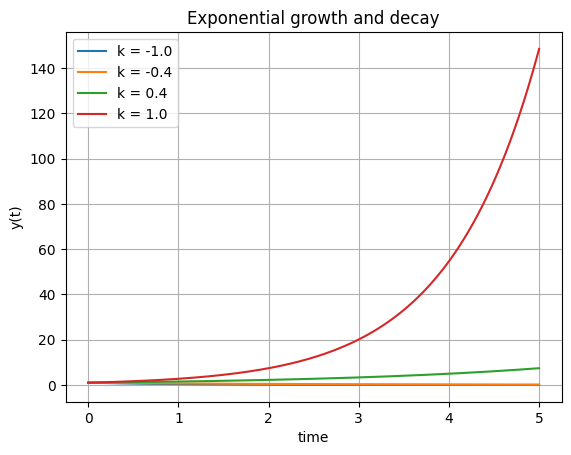

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 5, 400)
y0 = 1.0

for k in [-1.0, -0.4, 0.4, 1.0]:
    y = y0 * np.exp(k*t)
    plt.plot(t, y, label=f"k = {k}")

plt.xlabel("time")
plt.ylabel("y(t)")
plt.title("Exponential growth and decay")
plt.legend()
plt.grid()
plt.show()

### Exercise 1 — bacterial growth

A bacterial population initially contains $N_0=1000$ cells and grows according to

$$
\frac{dN}{dt}=0.4N,
$$

where $t$ is measured in hours.

1. Write down $N(t)$.
2. Calculate the population after 2 h.
3. How long does it take for the population to double?
4. What changes if the coefficient $0.4$ is replaced by $-0.4$?

## 2. An ODE as a rule for the slope

Consider

$$
\frac{dy}{dt}=f(t,y).
$$

If we know $t$ and $y$, the equation tells us the **slope** of the solution at that point.

This suggests a simple numerical method. Starting from $(t_0,y_0)$, take a small step $\Delta t$:

$$
y_{n+1}=y_n+\Delta t\,f(t_n,y_n).
$$

This is **Euler's method**.

It is important conceptually: even if we cannot find a formula for the solution, we can often calculate its evolution numerically.

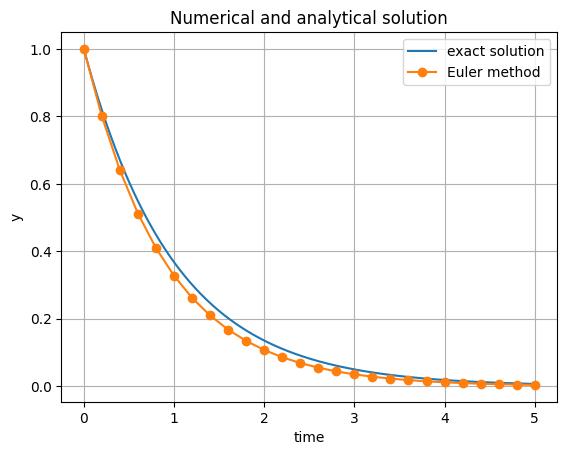

In [2]:
def euler(f, t0, y0, t_end, dt):
    t = np.arange(t0, t_end + dt, dt)
    y = np.zeros_like(t, dtype=float)
    y[0] = y0

    for n in range(len(t)-1):
        y[n+1] = y[n] + dt*f(t[n], y[n])

    return t, y

k = -1.0
f = lambda t, y: k*y

t_num, y_num = euler(f, 0, 1, 5, 0.2)
t_exact = np.linspace(0, 5, 400)

plt.plot(t_exact, np.exp(k*t_exact), label="exact solution")
plt.plot(t_num, y_num, "o-", label="Euler method")
plt.xlabel("time")
plt.ylabel("y")
plt.title("Numerical and analytical solution")
plt.legend()
plt.grid()
plt.show()

### Exercise 2 — step size

Repeat the calculation above with

$$
\Delta t=0.5,\quad 0.2,\quad 0.05.
$$

What happens as $\Delta t$ becomes smaller?

**Question:** Why is Euler's method only an approximation?

# Part II — A second-order ODE: the harmonic oscillator

## 3. A horizontal spring–mass system

We now consider a mass $m$ attached to a spring. The mass moves **horizontally**, so gravity does not contribute to the force in the direction of motion.

Let $x=0$ denote the equilibrium position.

Hooke's law gives

$$
F=-kx,
$$

where $k$ is the spring constant.

Newton's second law gives

$$
F=m\ddot{x}.
$$

Therefore

$$
m\ddot{x}=-kx,
$$

or

$$
\ddot{x}+\frac{k}{m}x=0.
$$

Define

$$
\omega_0=\sqrt{\frac{k}{m}}.
$$

Then

$$
\boxed{\ddot{x}+\omega_0^2x=0}.
$$

This is a **second-order ODE**.

### Why do we need two initial conditions?

For a first-order equation we specified one initial value, for example $y(0)$.

For the oscillator we need

$$
x(0)=x_0
$$

and

$$
\dot{x}(0)=v_0.
$$

Physically this makes sense: knowing only where the mass is does not tell us whether it is moving to the left or to the right.

Position **and** velocity determine the subsequent motion.

## 4. Solution using sine and cosine

We know that differentiating sine or cosine twice produces the negative of the original function:

$$
\frac{d^2}{dt^2}\cos(\omega_0t)
=-\omega_0^2\cos(\omega_0t).
$$

Therefore

$$
x(t)=A\cos(\omega_0t)+B\sin(\omega_0t)
$$

solves the oscillator equation.

The period is

$$
T=\frac{2\pi}{\omega_0}.
$$

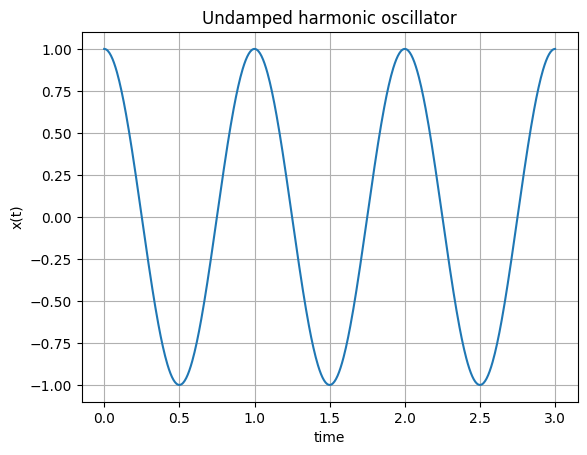

In [3]:
omega0 = 2*np.pi
t = np.linspace(0, 3, 600)

x0 = 1.0
v0 = 0.0

x = x0*np.cos(omega0*t) + (v0/omega0)*np.sin(omega0*t)
v = -x0*omega0*np.sin(omega0*t) + v0*np.cos(omega0*t)

plt.plot(t, x)
plt.xlabel("time")
plt.ylabel("x(t)")
plt.title("Undamped harmonic oscillator")
plt.grid()
plt.show()

## 5. Complex numbers make the solution systematic

Instead of guessing sine and cosine, try

$$
x(t)=Ae^{\lambda t}.
$$

Then

$$
\dot{x}=\lambda Ae^{\lambda t}
$$

and

$$
\ddot{x}=\lambda^2Ae^{\lambda t}.
$$

Substitution into

$$
\ddot{x}+\omega_0^2x=0
$$

gives

$$
(\lambda^2+\omega_0^2)Ae^{\lambda t}=0.
$$

Hence the **characteristic equation** is

$$
\lambda^2+\omega_0^2=0.
$$

Thus

$$
\lambda=\pm i\omega_0.
$$

Using Euler's formula,

$$
e^{i\phi}=\cos\phi+i\sin\phi,
$$

we recover the sine and cosine solution.

Complex numbers are therefore not introducing new physics. They provide a convenient mathematical language for oscillations.

## 6. Phase space

A second-order ODE can be rewritten as two first-order ODEs.

Define velocity

$$
v=\dot{x}.
$$

Then the harmonic oscillator becomes

$$
\dot{x}=v,
$$

$$
\dot{v}=-\omega_0^2x.
$$

The state of the oscillator is represented by a point in the space spanned by $(x,v)$.

As time passes, this point moves through **phase space**.

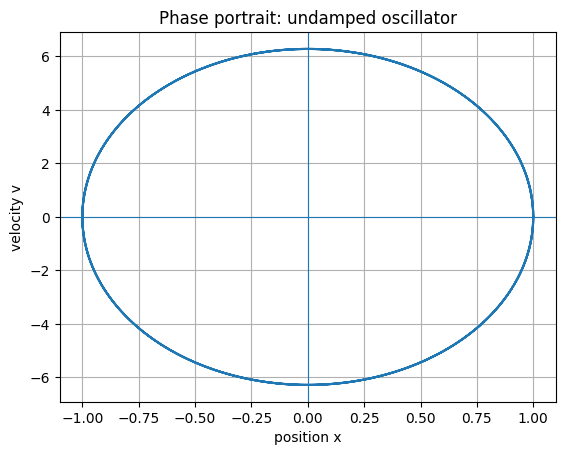

In [4]:
plt.plot(x, v)
plt.xlabel("position x")
plt.ylabel("velocity v")
plt.title("Phase portrait: undamped oscillator")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid()
plt.show()

The trajectory is closed: after one period, both position and velocity return to their initial values.

The oscillator does not lose energy.

### Exercise 3 — interpreting phase space

Identify the points in the phase portrait where:

1. the displacement is maximal,
2. the velocity is maximal,
3. the mass passes through equilibrium,
4. the mass changes its direction of motion.

In which direction does the trajectory move around the phase portrait?

# Part III — Damping

## 7. The damped oscillator

Real oscillators lose energy. A simple model assumes that the damping force is proportional to velocity:

$$
F_D=-b\dot{x}.
$$

Newton's equation becomes

$$
m\ddot{x}=-b\dot{x}-kx.
$$

Therefore

$$
m\ddot{x}+b\dot{x}+kx=0.
$$

Dividing by $m$ and defining

$$
2\delta=\frac{b}{m},
\qquad
\omega_0^2=\frac{k}{m},
$$

gives

$$
\boxed{\ddot{x}+2\delta\dot{x}+\omega_0^2x=0}.
$$

## 8. Characteristic equation

Again try

$$
x(t)=Ae^{\lambda t}.
$$

Substitution gives

$$
\lambda^2+2\delta\lambda+\omega_0^2=0.
$$

The two roots are

$$
\lambda_{1,2}
=
-\delta\pm\sqrt{\delta^2-\omega_0^2}.
$$

Everything depends on the expression

$$
\delta^2-\omega_0^2.
$$

This gives three qualitatively different types of motion.

## 9. Case I: underdamped motion — $\delta<\omega_0$

Now the square root is imaginary. Define

$$
\omega_d=\sqrt{\omega_0^2-\delta^2}.
$$

Then

$$
\lambda=-\delta\pm i\omega_d.
$$

The motion has the form

$$
x(t)=e^{-\delta t}
\left[
A\cos(\omega_dt)+B\sin(\omega_dt)
\right].
$$

The mass still oscillates, but its amplitude decreases exponentially.

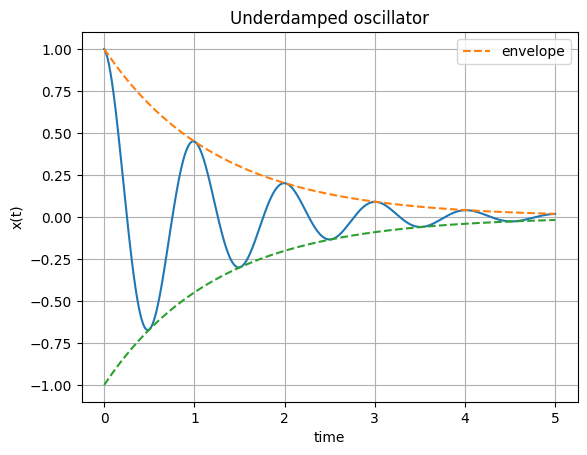

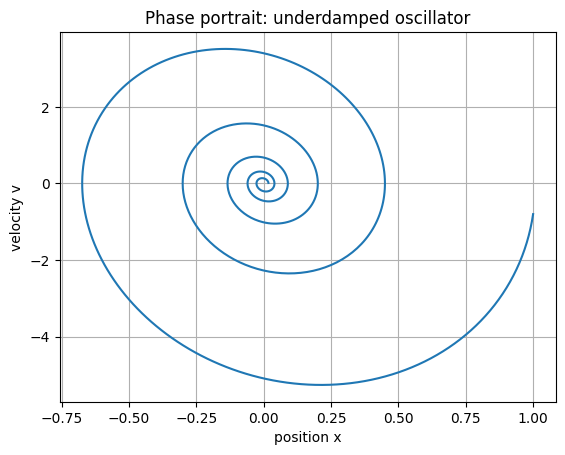

In [5]:
omega0 = 2*np.pi
delta = 0.8

t = np.linspace(0, 5, 1000)
omega_d = np.sqrt(omega0**2 - delta**2)

x = np.exp(-delta*t)*np.cos(omega_d*t)
v = np.exp(-delta*t)*(-delta*np.cos(omega_d*t)
                     -omega_d*np.sin(omega_d*t))

plt.plot(t, x)
plt.plot(t, np.exp(-delta*t), "--", label="envelope")
plt.plot(t, -np.exp(-delta*t), "--")
plt.xlabel("time")
plt.ylabel("x(t)")
plt.title("Underdamped oscillator")
plt.legend()
plt.grid()
plt.show()

plt.plot(x, v)
plt.xlabel("position x")
plt.ylabel("velocity v")
plt.title("Phase portrait: underdamped oscillator")
plt.grid()
plt.show()

The phase-space trajectory is now a spiral. Energy is continuously removed from the system, and the state approaches

$$
(x,v)=(0,0).
$$

## 10. Case II: the aperiodic limiting case — $\delta=\omega_0$

This case is also called **critical damping**.

The characteristic equation has one repeated root:

$$
\lambda=-\omega_0.
$$

The solution is

$$
x(t)=(A+Bt)e^{-\omega_0t}.
$$

This case is special: the system returns to equilibrium **as rapidly as possible without oscillating**.

Critical damping is useful when an object should return rapidly to its equilibrium position but should not overshoot.

## 11. Case III: creep case / overdamping — $\delta>\omega_0$

Now both roots are real and negative:

$$
\lambda_{1,2}
=
-\delta\pm\sqrt{\delta^2-\omega_0^2}.
$$

The solution is

$$
x(t)=A e^{\lambda_1t}+B e^{\lambda_2t}.
$$

There is no oscillation. The system slowly **creeps** back toward equilibrium.

Increasing damping beyond the critical value therefore does **not** make the system return faster. It makes the final relaxation slower.

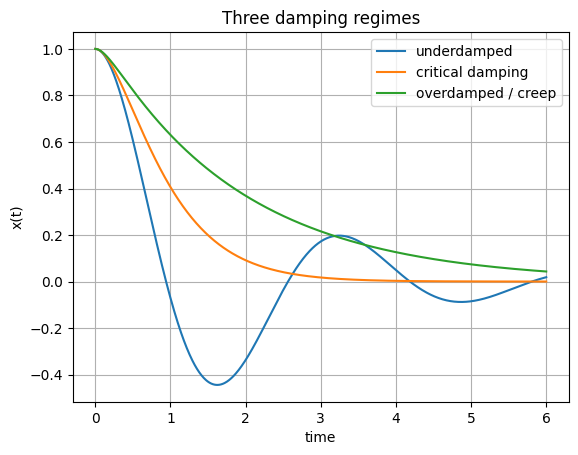

In [6]:
# Compare the three damping regimes.
# We choose x(0)=1 and v(0)=0.

omega0 = 2.0
t = np.linspace(0, 6, 800)

def damped_solution(t, omega0, delta, x0=1.0, v0=0.0):
    if delta < omega0:
        wd = np.sqrt(omega0**2-delta**2)
        A = x0
        B = (v0 + delta*x0)/wd
        x = np.exp(-delta*t)*(A*np.cos(wd*t)+B*np.sin(wd*t))
        v = np.gradient(x, t)
    elif np.isclose(delta, omega0):
        A = x0
        B = v0 + delta*x0
        x = (A+B*t)*np.exp(-delta*t)
        v = np.gradient(x, t)
    else:
        s = np.sqrt(delta**2-omega0**2)
        l1, l2 = -delta+s, -delta-s
        A = (v0-l2*x0)/(l1-l2)
        B = x0-A
        x = A*np.exp(l1*t)+B*np.exp(l2*t)
        v = A*l1*np.exp(l1*t)+B*l2*np.exp(l2*t)
    return x, v

cases = [
    (0.5, "underdamped"),
    (2.0, "critical damping"),
    (4.0, "overdamped / creep")
]

for delta, label in cases:
    xx, vv = damped_solution(t, omega0, delta)
    plt.plot(t, xx, label=label)

plt.xlabel("time")
plt.ylabel("x(t)")
plt.title("Three damping regimes")
plt.legend()
plt.grid()
plt.show()

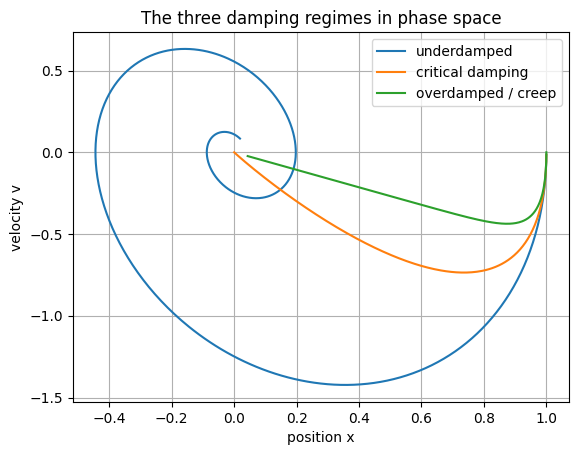

In [7]:
for delta, label in cases:
    xx, vv = damped_solution(t, omega0, delta)
    plt.plot(xx, vv, label=label)

plt.xlabel("position x")
plt.ylabel("velocity v")
plt.title("The three damping regimes in phase space")
plt.legend()
plt.grid()
plt.show()

### Exercise 4 — damping

Consider

$$
\ddot{x}+6\dot{x}+9x=0.
$$

1. Determine $\delta$ and $\omega_0$.
2. Is the motion underdamped, critically damped, or overdamped?
3. Determine the roots of the characteristic equation.
4. Sketch qualitatively how $x(t)$ should behave for $x(0)>0$ and $\dot{x}(0)=0$.
5. Sketch the corresponding phase-space trajectory before using Python to check your prediction.

# Part IV — The driven oscillator

## 12. Adding an external periodic force

Suppose we periodically push the mass:

$$
F(t)=F_0\cos(\omega t).
$$

The equation becomes

$$
m\ddot{x}+b\dot{x}+kx=F_0\cos(\omega t).
$$

There are now two important frequencies:

- $\omega_0$: the natural frequency of the oscillator,
- $\omega$: the frequency of the external force.

After the transient motion has decayed, the oscillator moves with the frequency of the external force.

## 13. Complex representation of the driving force

We write

$$
F(t)=\operatorname{Re}\left(F_0e^{i\omega t}\right)
$$

and seek a complex solution

$$
\tilde{x}(t)=\tilde{A}e^{i\omega t}.
$$

Then

$$
\dot{\tilde{x}}=i\omega\tilde{A}e^{i\omega t}
$$

and

$$
\ddot{\tilde{x}}=-\omega^2\tilde{A}e^{i\omega t}.
$$

Substitution gives

$$
(-m\omega^2+i b\omega+k)\tilde{A}e^{i\omega t}
=
F_0e^{i\omega t}.
$$

Therefore

$$
\boxed{
\tilde{A}
=
\frac{F_0}{k-m\omega^2+i b\omega}
}.
$$

The physical displacement is the real part of the complex solution.

## 14. Amplitude and phase

The magnitude of the complex amplitude is

$$
A(\omega)
=
\frac{F_0}
{\sqrt{(k-m\omega^2)^2+(b\omega)^2}}.
$$

The phase lag $\phi$ satisfies

$$
\tan\phi=
\frac{b\omega}{k-m\omega^2}.
$$

Thus the steady-state motion can be written

$$
x(t)=A(\omega)\cos(\omega t-\phi).
$$

Both the amplitude and the phase depend on the driving frequency.

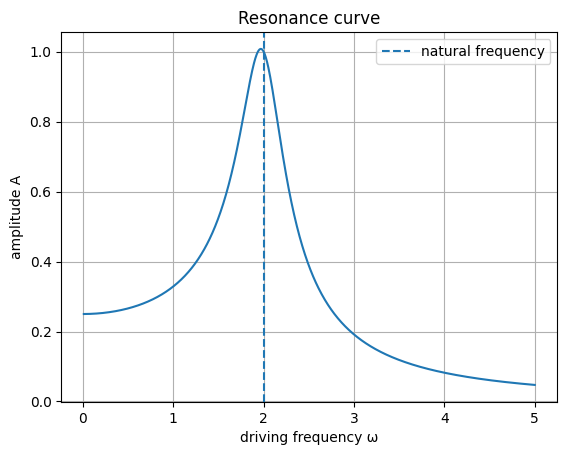

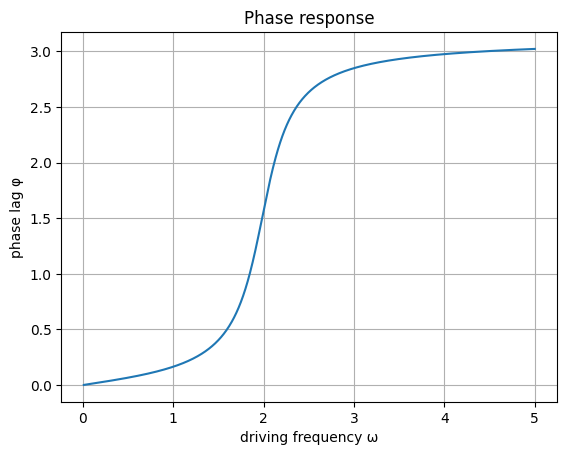

In [8]:
m = 1.0
k = 4.0
b = 0.5
F0 = 1.0

omega = np.linspace(0.01, 5, 1000)

A = F0 / np.sqrt((k-m*omega**2)**2 + (b*omega)**2)
phi = np.arctan2(b*omega, k-m*omega**2)

plt.plot(omega, A)
plt.axvline(np.sqrt(k/m), linestyle="--", label="natural frequency")
plt.xlabel("driving frequency ω")
plt.ylabel("amplitude A")
plt.title("Resonance curve")
plt.legend()
plt.grid()
plt.show()

plt.plot(omega, phi)
plt.xlabel("driving frequency ω")
plt.ylabel("phase lag φ")
plt.title("Phase response")
plt.grid()
plt.show()

### What is resonance?

Near the natural frequency, the external force can transfer energy very efficiently to the oscillator. The response amplitude becomes large.

Damping limits the resonance amplitude.

The driven oscillator therefore brings together all of the ideas developed so far:

- differential equations,
- initial conditions,
- second-order dynamics,
- complex numbers,
- oscillation,
- damping,
- amplitude,
- phase,
- and long-time behaviour.

### Exercise 5 — resonance

For

$$
m=1,\qquad k=4,\qquad F_0=1,
$$

compare the resonance curves for

$$
b=0.1,\quad 0.5,\quad 1.5.
$$

1. Which oscillator has the largest maximum amplitude?
2. What happens to the width of the resonance peak as damping increases?
3. What happens to the phase near resonance?
4. Explain physically why an oscillator cannot build up an arbitrarily large amplitude when damping is present.

# Part V — From mechanics to biology

## 15. A biological oscillator: predator and prey

Oscillations also occur in biological systems.

Consider a population of prey $N(t)$ and predators $P(t)$.

A simple model is the **Lotka–Volterra model**:

$$
\frac{dN}{dt}=aN-bNP,
$$

$$
\frac{dP}{dt}=cNP-dP.
$$

Here:

- $aN$ describes growth of the prey population,
- $bNP$ describes prey being consumed by predators,
- $cNP$ describes predator reproduction supported by prey,
- $dP$ describes decline of predators when prey is absent.

Unlike the spring oscillator, these equations are **nonlinear** because they contain the product $NP$.

### 15.1 Why can this system oscillate?

Imagine starting with many prey and few predators.

1. The prey population grows.
2. Abundant prey allows the predator population to increase.
3. More predators reduce the prey population.
4. With less prey available, the predator population decreases.
5. With fewer predators, the prey population can recover.

The cycle can then repeat.

We will solve these equations numerically.

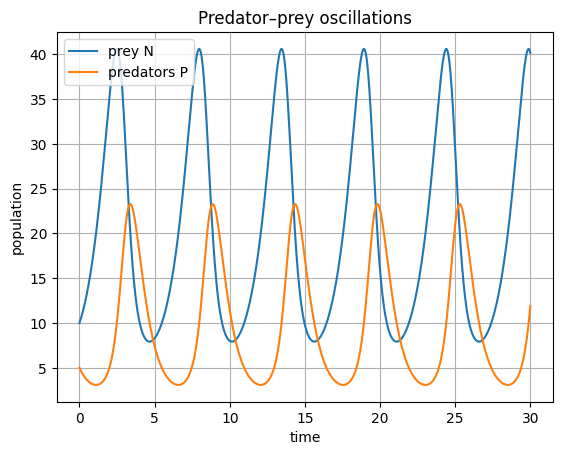

In [9]:
# Simple Runge-Kutta (RK4) solver for two coupled ODEs.
# This avoids requiring scipy and works well in JupyterLite.

def rk4_system(f, y0, t):
    y = np.zeros((len(t), len(y0)), dtype=float)
    y[0] = y0

    for i in range(len(t)-1):
        h = t[i+1] - t[i]
        k1 = np.asarray(f(t[i], y[i]))
        k2 = np.asarray(f(t[i] + h/2, y[i] + h*k1/2))
        k3 = np.asarray(f(t[i] + h/2, y[i] + h*k2/2))
        k4 = np.asarray(f(t[i] + h, y[i] + h*k3))
        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6

    return y

a = 1.0
b = 0.1
c = 0.075
d = 1.5

def predator_prey(t, y):
    N, P = y
    dN = a*N - b*N*P
    dP = c*N*P - d*P
    return [dN, dP]

t_bio = np.linspace(0, 30, 1500)
solution = rk4_system(predator_prey, [10, 5], t_bio)

N = solution[:,0]
P = solution[:,1]

plt.plot(t_bio, N, label="prey N")
plt.plot(t_bio, P, label="predators P")
plt.xlabel("time")
plt.ylabel("population")
plt.title("Predator–prey oscillations")
plt.legend()
plt.grid()
plt.show()

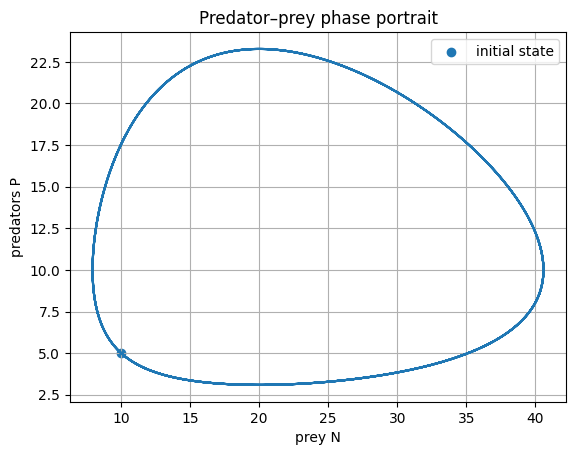

In [10]:
plt.plot(N, P)
plt.scatter([N[0]], [P[0]], label="initial state")
plt.xlabel("prey N")
plt.ylabel("predators P")
plt.title("Predator–prey phase portrait")
plt.legend()
plt.grid()
plt.show()

## 16. Mechanical and biological phase spaces

There is an important similarity.

For the mechanical oscillator, the state is

$$
(x,v).
$$

For the predator–prey system, the state is

$$
(N,P).
$$

In both cases, a single point in phase space specifies the state of the system, and the ODE determines how that point moves.

But there is also an important difference:

$$
\dot{x}=v,\qquad
\dot{v}=-\omega_0^2x
$$

is a **linear** system, whereas

$$
\dot{N}=aN-bNP,\qquad
\dot{P}=cNP-dP
$$

is **nonlinear**.

The idea of a dynamical system and its phase space applies to both.

# Exercise 6 — biological oscillator

Use the Lotka–Volterra model above.

### A. Reading the equations

1. What happens to the prey population if $P=0$?
2. What happens to the predator population if $N=0$?
3. Which term couples the two populations?
4. Why is this system nonlinear?

### B. Exploring the numerical solution

Change the initial populations from

$$
(N_0,P_0)=(10,5)
$$

to

$$
(N_0,P_0)=(20,5).
$$

Plot both $N(t)$ and $P(t)$.

- Which population reaches its maximum first?
- Explain the time delay between the prey and predator maxima.

### C. Phase space

Plot $P$ against $N$.

- Is the trajectory closed?
- What does one complete orbit represent biologically?
- Compare this plot with the phase portrait of the undamped harmonic oscillator.

### D. Changing a parameter

Increase the predator death rate $d$.

Predict **before running the code** what you expect to happen. Then test your prediction numerically.

### E. Challenge

Find the state $(N^*,P^*)$ for which neither population changes:

$$
\frac{dN}{dt}=0,
\qquad
\frac{dP}{dt}=0.
$$

There is a trivial solution $(0,0)$ and a second, biologically interesting equilibrium.

Find it in terms of $a,b,c,d$ and mark this point in the phase-space plot.

# 17. Summary

We started with the simple first-order equation

$$
\dot{y}=ky
$$

and ended with coupled nonlinear equations describing interacting populations.

Along the way we encountered:

$$
\dot{y}=f(t,y)
$$

as a general first-order ODE,

$$
\ddot{x}+\omega_0^2x=0
$$

for an undamped oscillator,

$$
\ddot{x}+2\delta\dot{x}+\omega_0^2x=0
$$

for a damped oscillator, and

$$
m\ddot{x}+b\dot{x}+kx=F_0\cos(\omega t)
$$

for a driven oscillator.

The central idea is always the same:

> **A differential equation specifies how the present state determines its rate of change.**

Initial conditions determine where the system starts. The ODE determines where it goes.

Phase space gives us a way to visualize this evolution even when an analytical solution is difficult or impossible to obtain.

# Optional final exercise — identify the dynamics

For each observation, decide which model is most appropriate and explain your choice.

1. A concentration decreases at a rate proportional to its current concentration.
2. A mass on an ideal spring oscillates indefinitely.
3. A displaced system returns to equilibrium as rapidly as possible without overshooting.
4. A strongly damped system slowly returns to equilibrium without oscillating.
5. A periodically forced system responds especially strongly near one frequency.
6. Two interacting populations repeatedly rise and fall with a time delay between their maxima.

For each case, identify:

- the relevant ODE or system of ODEs,
- whether it is first or second order,
- whether it is linear or nonlinear,
- and what you would expect its trajectory to look like in time or phase space.